Setup

Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython


  Activating project at `c:\Users\micha\GeneCircuitsRL`


  0.826262 seconds (2.26 M allocations: 126.101 MiB, 7.19% gc time, 99.49% compilation time)
  0.127359 seconds (897.33 k allocations: 98.414 MiB, 18.84% gc time, 32.80% compilation time)


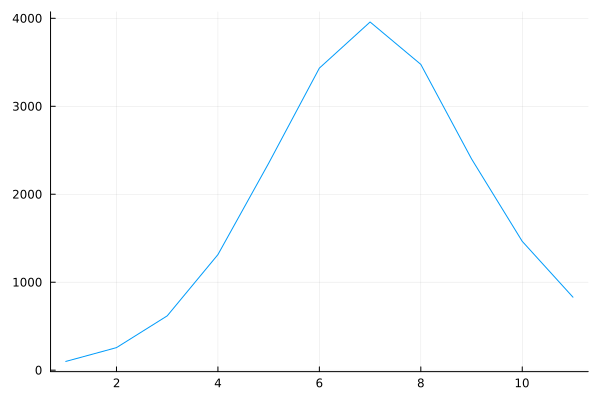

  5.117649 seconds (69.52 M allocations: 8.081 GiB, 11.98% gc time, 0.69% compilation time)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from juliacall import Main as jl
from juliacall import Pkg as jlPkg

jlPkg.activate(".")
#jlPkg.instantiate() #run the first time using this repo
jl.include("models/model_host_aware_adapt_scale.jl")

In [2]:
import os
import gymnasium as gym
from gymnasium import spaces
import numpy as np
import torch
import random
from gymnasium.utils import seeding
from stable_baselines3 import PPO

log_dir = "logs/rl_host"
model_path = os.path.join(log_dir, "ppo_model")

In [3]:
class CustomEnv(gym.Env):
    metadata = {"render_modes": []}

    def __init__(self, max_episode_steps=5):
        super(CustomEnv, self).__init__()

        self.obs_dim = 1           # observation = reward (scalar)
        self.action_dim = 1        # action = scalar in [-1, 1]
        self.uncertain_dim = 3     # hidden state (uncertain parameters)
        self.n_steps = max_episode_steps

        self.observation_space = spaces.Box(
            low=-np.inf,
            high=np.inf,
            shape=(1, self.n_steps * (self.obs_dim + self.action_dim)),
            dtype=np.float32,
        )

        self.action_space = spaces.Box(
            low=0,
            high=1,
            shape=(self.action_dim,),
            dtype=np.float32,
        )

        self.max_episode_steps = max_episode_steps
        self.current_step = 0
        self.uncertain = np.zeros(self.uncertain_dim, dtype=np.float32)
        self.effective_observation = np.zeros(self.observation_space.shape, dtype=np.float32)

    def seed(self, seed=None):
        self._np_random, seed = seeding.np_random(seed)
        np.random.seed(seed)
        random.seed(seed)
        torch.manual_seed(seed)
        jl.seval(f"Random.seed!({seed})")  # sync seed with Julia
        return [seed]

    def reset(self, seed=None, options=None):
        if options is not None and "uncertain" in options:
            self.uncertain = np.array(options["uncertain"], dtype=np.float32)
        else:
            self.uncertain = np.random.rand(self.uncertain_dim).astype(np.float32)
            # Sample from N(0.5, 0.5^2) truncated to [0, 1]
            # Note: this parameter is later rescaled by a factor of 2, making it
            # equivalent to sampling from N(1, 1^2) truncated to [0, 2].
            mu, sigma = 0.5, 0.5
            x = np.random.normal(mu, sigma)
            while x < 0.0 or x > 1.0:
                x = np.random.normal(mu, sigma)
            self.uncertain[1] = np.float32(x)

        if seed is not None:
            self.seed(seed)

        self.current_step = 0
        self.effective_observation[:] = 0.0

        info = {}
        return self.effective_observation.copy(), info

    def step(self, action):
        action = np.clip(action, -1, 1).astype(np.float32)
        action_scalar = float(action[0])


        # compute reward (observation) from Julia
        reward = float(jl.reward(action_scalar, self.uncertain))
        noise_std = 0.1  # standard deviation of the noise
        obs_vector = np.array([[reward + np.random.normal(0, noise_std)]], dtype=np.float32)


        # history is effective observation as policy not only received most recent obsevation but the whole history
        if self.current_step < self.max_episode_steps:
            obs_start = self.current_step * (self.obs_dim + self.action_dim)
            act_start = obs_start + self.obs_dim
            self.effective_observation[:, obs_start:act_start] = obs_vector
            self.effective_observation[:, act_start:act_start + self.action_dim] = action

        self.current_step += 1
        terminated = self.current_step >= self.max_episode_steps
        truncated = False
        info = {}

        return self.effective_observation.copy(), reward, terminated, truncated, info


Training

In [75]:
import os
import pandas as pd
import seaborn as sns

from stable_baselines3 import PPO
from stable_baselines3.common.monitor import Monitor

os.makedirs(log_dir, exist_ok=True)

SEED = 1234

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
jl.seval(f"Random.seed!({SEED})") 
env = CustomEnv()
env.seed(SEED)
env.reset(seed=SEED)
env = Monitor(env, filename=log_dir)

model = PPO(
    "MlpPolicy", 
    env,
    verbose=1,
    tensorboard_log=log_dir, 
    seed=SEED
)


Using cpu device
Wrapping the env in a DummyVecEnv.


In [ ]:
# Train the model
model.learn(total_timesteps=1_000_000)

# Save the model
model.save(os.path.join(log_dir, "ppo_model"))

Logging to logs/rl_host/PPO_1
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 5        |
|    ep_rew_mean     | 4.43     |
| time/              |          |
|    fps             | 295      |
|    iterations      | 1        |
|    time_elapsed    | 6        |
|    total_timesteps | 2048     |
---------------------------------
-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 5           |
|    ep_rew_mean          | 5.16        |
| time/                   |             |
|    fps                  | 297         |
|    iterations           | 2           |
|    time_elapsed         | 13          |
|    total_timesteps      | 4096        |
| train/                  |             |
|    approx_kl            | 0.021227287 |
|    clip_fraction        | 0.191       |
|    clip_range           | 0.2         |
|    entropy_loss         | -1.4        |
|    explained_variance   | -0.043      |


Evaluation

In [4]:
import os
import pandas as pd
import seaborn as sns

from stable_baselines3 import PPO
from stable_baselines3.common.monitor import Monitor

# test environment
env = CustomEnv()

log_dir = "logs/rl_host"
model_path = os.path.join(log_dir, "ppo_model")

model_path = os.path.join(log_dir, "ppo_model")
monitor_file = os.path.join(log_dir, "monitor.csv")

model = PPO.load(model_path)


df = pd.read_csv(monitor_file, skiprows=1)

C:\Users\micha\AppData\Local\Temp\ipykernel_9840\2942570546.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(fontsize=14)


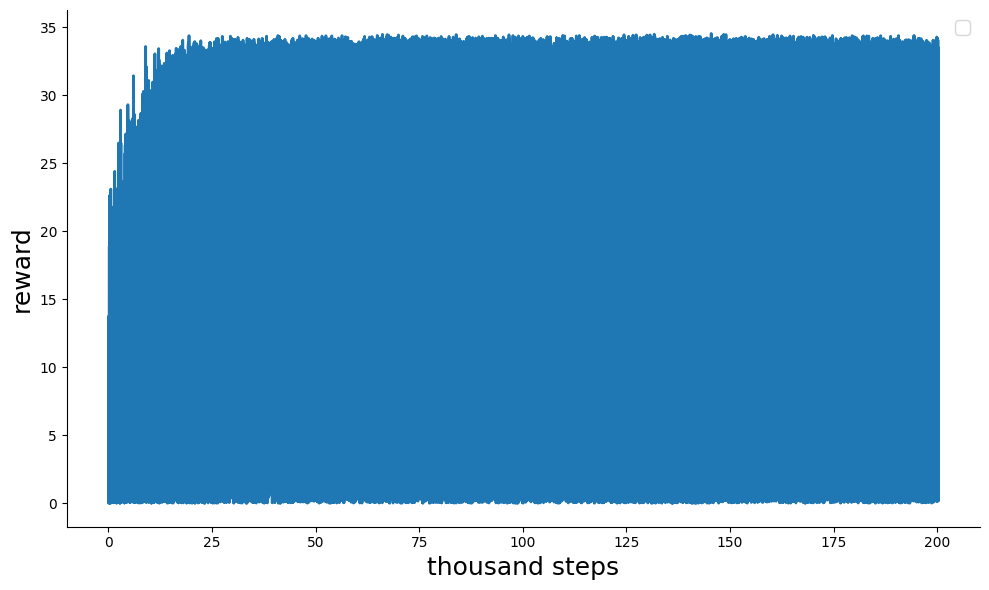

In [5]:
plt.figure(figsize=(10, 6))
sns.lineplot(x=[x / 1e3 for x in range(len(df))], y=df["r"], linewidth=2)

plt.xlabel("thousand steps", fontsize=18)
plt.ylabel("reward", fontsize=18)
plt.legend(fontsize=14)
sns.despine()

plt.tight_layout()
plt.savefig("learning_curve_1.pdf", format="pdf")
plt.show()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


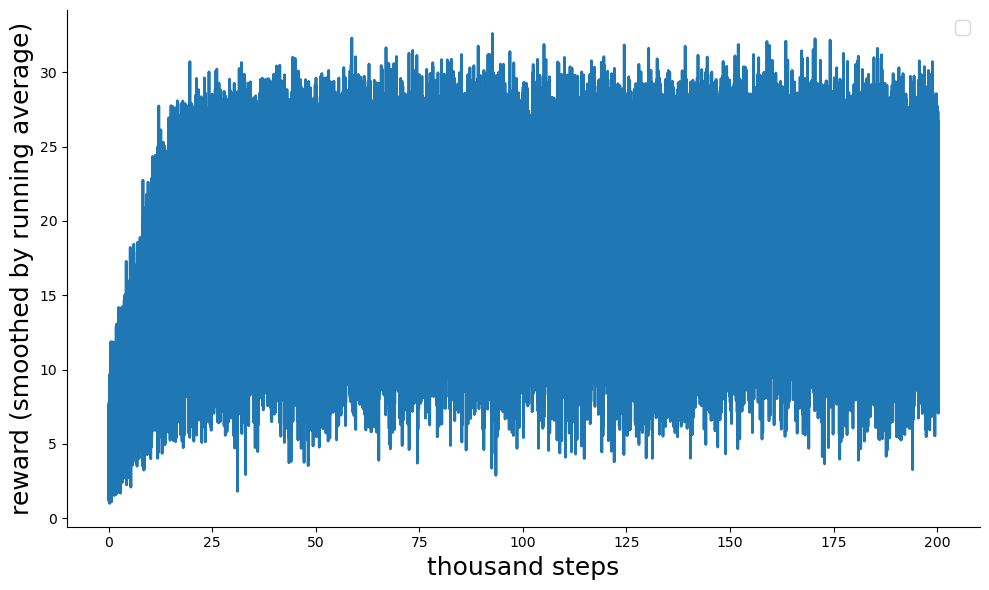

In [ ]:
plt.figure(figsize=(10, 6))

# Apply running average (rolling mean) with a window size of 5
df["r_smoothed"] = df["r"].rolling(window=5).mean()

sns.lineplot(x=[x / 1e3 for x in range(len(df))], y=df["r_smoothed"], linewidth=2)

plt.xlabel("thousand steps", fontsize=18)
plt.ylabel("reward (smoothed by running average)", fontsize=18)
plt.legend(fontsize=14)
sns.despine()

plt.tight_layout()
plt.savefig("learning_curve_2.pdf", format="pdf")
plt.show()

[0.61113816] 3.1977448
Reward at step 0: 3.021339517707651
[0.52143157] 1.9716898
Reward at step 1: 1.9316741267188016
[0.74279386] 4.4640913
Reward at step 2: 4.3662173340130295
[0.80491227] 4.734118
Reward at step 3: 4.510028519728235
[0.8089962] 4.690119
Reward at step 4: 4.503362881546409


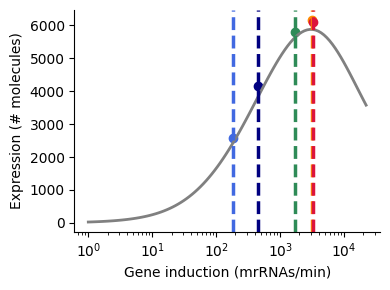

In [6]:
import numpy as np
import matplotlib.pyplot as plt


np.random.seed(0) # Due to trancation being performed by rejecting samples outside of the range this seed need to be fixed as well
obs, info = env.reset(0)

vals = np.zeros(100)
for i in range(100):
    vals[i] = jl.denormalize_reward( jl.reward(i/100, env.uncertain))

plt.figure(figsize=(4, 3))
plt.plot(np.array([jl.normalize_numg0(x) for x in np.linspace(0, 1, 100)]), vals, label='Reward landscape', color='gray', linewidth=2)

colors = ['navy', 'royalblue', 'seagreen', 'darkorange', 'crimson']
n_steps = len(colors)


for step in range(n_steps):
    action, _states = model.predict(obs, deterministic=True)
    plt.axvline(x= jl.normalize_numg0(action[0]), color=colors[step], linestyle='--', linewidth=2.5, label=f'Step {step}')
    obs, reward, terminated, truncated, info = env.step(action)
    print(action,obs[0,2*step])
    plt.scatter(jl.normalize_numg0(action[0]),jl.denormalize_reward(obs[0,2*step]),color=colors[step])
    print(f"Reward at step {step}: {reward}")

sns.despine()
plt.xscale('log')
plt.xlabel('Gene induction (mrRNAs/min)')
plt.ylabel('Expression (# molecules)')
# plt.legend(title='Legend', loc='best', frameon=True, facecolor='white')
plt.tight_layout()
plt.savefig("progression_1.pdf", format="pdf")
plt.show()


[0.61113816] 3.952541
Reward at step 0: 3.9942168893893872
[0.5308666] 4.5126896
Reward at step 1: 4.518316180677069
[0.5224154] 4.3146462
Reward at step 2: 4.528265822619889
[0.5281189] 4.686589
Reward at step 3: 4.522561461816958
[0.52399176] 4.3477645
Reward at step 4: 4.5271082557639595


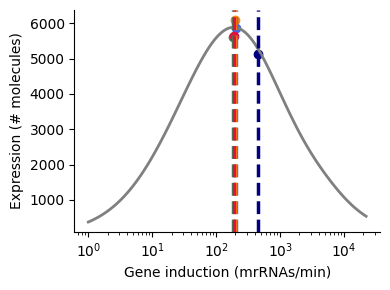

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(3)
obs, info = env.reset(2)



vals = np.zeros(100)
for i in range(100):
    vals[i] = jl.denormalize_reward( jl.reward(i/100, env.uncertain))


plt.figure(figsize=(4, 3))
plt.plot(np.array([jl.normalize_numg0(x) for x in np.linspace(0, 1, 100)]), vals, label='Reward landscape', color='gray', linewidth=2)


colors = ['navy', 'royalblue', 'seagreen', 'darkorange', 'crimson']
n_steps = len(colors)

for step in range(n_steps):
    action, _states = model.predict(obs, deterministic=True)
    plt.axvline(x= jl.normalize_numg0(action[0]), color=colors[step], linestyle='--', linewidth=2.5, label=f'Step {step}')
    obs, reward, terminated, truncated, info = env.step(action)
    print(action,obs[0,2*step])
    plt.scatter(jl.normalize_numg0(action[0]),jl.denormalize_reward(obs[0,2*step]),color=colors[step])
    print(f"Reward at step {step}: {reward}")

sns.despine()

plt.xscale('log')
plt.xlabel('Gene induction (mrRNAs/min)')
plt.ylabel('Expression (# molecules)')
# plt.legend(title='Legend', loc='best', frameon=True, facecolor='white')
plt.tight_layout()
plt.savefig("progression_2.pdf", format="pdf")
plt.show()


[0.61113816] 2.2958364
Reward at step 0: 2.1194313294702494
[0.5038188] 1.0572686
Reward at step 1: 1.0172529149267564
[0.7494846] 4.2646303
Reward at step 2: 4.166756735818425
[0.9046369] 6.0199356
Reward at step 3: 5.795846116100243
[0.92670035] 5.9948177
Reward at step 4: 5.808061737025085


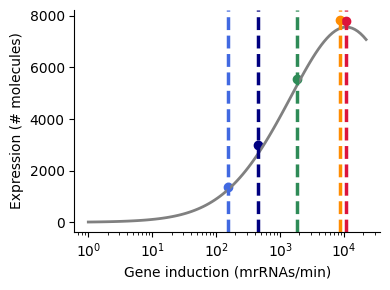

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(13)
obs, info = env.reset(0)

vals = np.zeros(100)
for i in range(100):
    vals[i] = jl.denormalize_reward( jl.reward(i/100, env.uncertain))


plt.figure(figsize=(4, 3))
plt.plot(np.array([jl.normalize_numg0(x) for x in np.linspace(0, 1, 100)]), vals, label='Reward landscape', color='gray', linewidth=2)


colors = ['navy', 'royalblue', 'seagreen', 'darkorange', 'crimson']
n_steps = len(colors)


for step in range(n_steps):
    action, _states = model.predict(obs, deterministic=True)
    plt.axvline(x= jl.normalize_numg0(action[0]), color=colors[step], linestyle='--', linewidth=2.5, label=f'Step {step}')
    obs, reward, terminated, truncated, info = env.step(action)
    print(action,obs[0,2*step])
    plt.scatter(jl.normalize_numg0(action[0]),jl.denormalize_reward(obs[0,2*step]),color=colors[step])
    print(f"Reward at step {step}: {reward}")

sns.despine()
plt.xscale('log')
plt.xlabel('Gene induction (mrRNAs/min)')
plt.ylabel('Expression (# molecules)')
# plt.legend(title='Legend', loc='best', frameon=True, facecolor='white')
plt.tight_layout()
plt.savefig("progression_3.pdf", format="pdf")
plt.show()


In [ ]:
first_rewards = np.zeros(100)
second_rewards = np.zeros(100)
third_rewards = np.zeros(100)
forth_rewards = np.zeros(100)
fifth_rewards = np.zeros(100)

env.seed(0)

for i in range(100):
    obs, info = env.reset() 
    vals = np.zeros(100)
    for j in range(100):
        vals[j] = jl.reward(j/100, env.uncertain)
    value = np.max(vals)
    action, _states = model.predict(obs, deterministic=True)
    obs, reward, terminated, truncated, info = env.step(action)
    first_rewards[i] = (reward - value)
    action, _states = model.predict(obs, deterministic=True)
    obs, reward, terminated, truncated, info = env.step(action)
    second_rewards[i] = (reward - value)
    action, _states = model.predict(obs, deterministic=True)
    obs, reward, terminated, truncated, info = env.step(action)
    third_rewards[i] = (reward - value)
    action, _states = model.predict(obs, deterministic=True)
    obs, reward, terminated, truncated, info = env.step(action)
    forth_rewards[i] = (reward - value)
    action, _states = model.predict(obs, deterministic=True)
    obs, reward, terminated, truncated, info = env.step(action)
    fifth_rewards[i] = (reward - value)



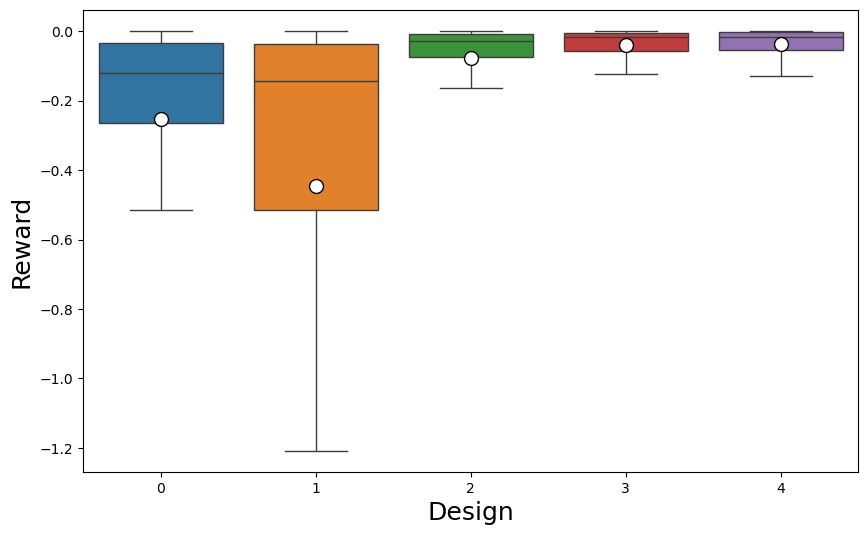

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.boxplot(
    data=[first_rewards, second_rewards, third_rewards, forth_rewards, fifth_rewards],
    showfliers=False,  
    showmeans=True,  
    meanprops={"marker":"o", "markerfacecolor":"white", "markeredgecolor":"black", "markersize":10}
)
plt.xlabel("Design", fontsize=18)
plt.ylabel("Reward", fontsize=18)
plt.show()


C:\Users\micha\AppData\Local\Temp\ipykernel_13356\3824309447.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(range(1, 6))


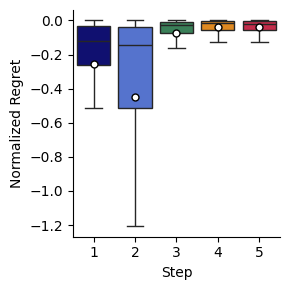

In [263]:
import seaborn as sns
import matplotlib.pyplot as plt

colors = ['navy', 'royalblue', 'seagreen', 'darkorange', 'crimson']

plt.figure(figsize=(3, 3))
ax = sns.boxplot(
    data=[first_rewards, second_rewards, third_rewards, forth_rewards, fifth_rewards],
    palette=colors,
    showfliers=False,
    showmeans=True,
    meanprops={
        "marker": "o",
        "markerfacecolor": "white",
        "markeredgecolor": "black",
        "markersize": 5
    },
)

plt.xlabel("Step")
plt.ylabel("Normalized Regret")
ax.set_xticklabels(range(1, 6))
sns.despine()

plt.tight_layout()
plt.savefig("boxplot.pdf", bbox_inches="tight")
plt.show()


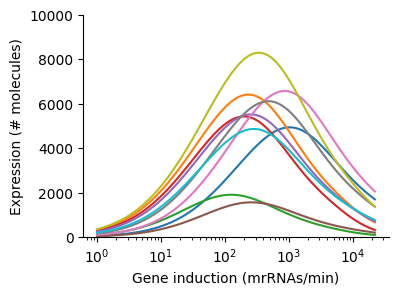

In [257]:
SEED = 2

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
jl.seval(f"Random.seed!({SEED})")  # your Julia seed
env.seed(SEED)
env.reset(seed=SEED)

import matplotlib.pyplot as plt
import numpy as np
import torch

# Number of samples along action dimension
n_points = 100
x = np.linspace(0, 1, n_points)

x_log = np.linspace(0, 10, n_points)

x_axis = np.exp(x_log)  # shape (n_points, 1)

# Number of different uncertain parameters to visualize
n_curves = 10

plt.figure(figsize=(4, 3))

for _ in range(n_curves):
    env.reset()
    vals = np.array([jl.denormalize_reward(jl.reward(a, env.uncertain)) for a in x])
    plt.plot(x_axis, vals, label=f'unc={unc.round(2)}')
plt.xscale('log')
plt.xlabel('Gene induction (mrRNAs/min)')
plt.ylabel('Expression (# molecules)')
sns.despine()
plt.tight_layout()
plt.ylim(0, 10000)
plt.savefig("curves.pdf", format="pdf")
plt.show()



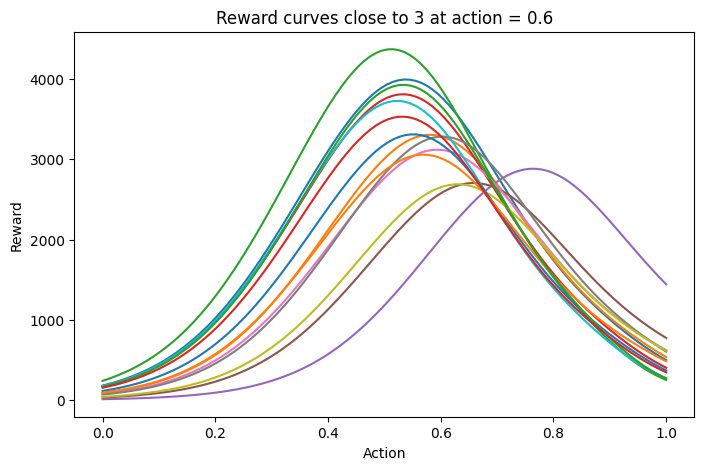

In [10]:
SEED = 2

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
jl.seval(f"Random.seed!({SEED})")
env.seed(SEED)
env.reset(seed=SEED)

import matplotlib.pyplot as plt
import numpy as np
import torch

n_points = 100
x = np.linspace(0, 1, n_points)

n_curves = 300
target_action = 0.7
target_value = 2.0
tol = 0.2  # closeness threshold

plt.figure(figsize=(8, 5))

for _ in range(n_curves):
    env.reset()
    unc = env.uncertain
    vals = np.array([jl.denormalize_reward(jl.reward(a, unc)) for a in x])

    # --- filter condition ---
    reward_at_target = jl.reward(target_action, unc)
    if abs(reward_at_target - target_value) > tol:
        continue  # skip this curve


    plt.plot(x, vals, label=f'unc={unc.round(2)}')


plt.xlabel('Action')
plt.ylabel('Reward')
plt.savefig("selected_curves.pdf", format="pdf")
plt.title('Reward curves close to 3 at action = 0.6')
plt.show()


## Bayesian optimization Baseline

In [ ]:
import numpy as np
import torch
import random
import matplotlib.pyplot as plt

from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel, WhiteKernel


# ----- Collect Data -----

n_points = 30
x = np.linspace(0, 1, n_points)
n_curves = 100

X_list = []
y_list = []


for i in range(n_curves):
    env.reset(i)
    unc = env.uncertain
    
    for a in x:
        reward = jl.reward(a, unc) + np.random.normal(0, 0.1) # Use the same noise as in RL
        X_list.append(np.concatenate([[a]]))
        y_list.append(reward)

mean_estimate = np.mean(y_list)
X = np.array(X_list)
y = np.array(y_list-mean_estimate)
# Kernel: σ² * RBF(ℓ) + σ_noise²
kernel = (
    ConstantKernel(1.0, (1e-3, 1e3)) *
    RBF(length_scale=1.0, length_scale_bounds=(1e-3, 1e3)) +
    WhiteKernel(noise_level=1.0, noise_level_bounds=(1e-6, 1e1))
)

gp = GaussianProcessRegressor(
    kernel=kernel,
    n_restarts_optimizer=10,
    random_state=SEED
)

gp.fit(X, y)

print("Learned kernel:")
print(gp.kernel_)

# Extract parameters
signal_variance = gp.kernel_.k1.k1.constant_value
lengthscale = gp.kernel_.k1.k2.length_scale
noise_variance = gp.kernel_.k2.noise_level

print("\nEstimated hyperparameters:")
print("Signal variance (σ²):", signal_variance)
print("Lengthscale (ℓ):", lengthscale)
print("Noise variance (σ_noise²):", noise_variance)
print("Mean (empirical):", mean_estimate)


Learned kernel:
1.35**2 * RBF(length_scale=0.28) + WhiteKernel(noise_level=1.65)

Estimated hyperparameters:
Signal variance (σ²): 1.8096485755130909
Lengthscale (ℓ): 0.27950759476444614
Noise variance (σ_noise²): 1.6511385314282774
Mean (empirical): 1.8222793763777596

In [ ]:
signal_variance = 1.8096485755130909
lengthscale = 0.27950759476444614
noise_variance =  1.6511385314282774
prior_mean = 1.8222793763777596

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from skopt import gp_minimize
from skopt.learning import GaussianProcessRegressor
from skopt.learning.gaussian_process.kernels import ConstantKernel, Matern, WhiteKernel


colors = ['navy', 'royalblue', 'seagreen', 'darkorange', 'crimson']
n_steps = len(colors)

all_diffs = np.zeros((200, n_steps)) 

for seed in range(200):
    obs, info = env.reset(seed)
    uncertain_fixed = env.uncertain.copy()  # fix uncertain for this run

    expression_rl = np.zeros(n_steps)
    for step in range(n_steps):
        action, _states = model.predict(obs, deterministic=True)
        obs, reward, terminated, truncated, info = env.step(action)
        expression_rl[step] = obs[0, 2*step]

    kernel = (
        ConstantKernel(signal_variance, constant_value_bounds="fixed") *
        Matern(length_scale=lengthscale, length_scale_bounds="fixed", nu=2.5) +
        WhiteKernel(noise_level=noise_variance, noise_level_bounds="fixed")
    )
    base_gp = GaussianProcessRegressor(kernel=kernel, normalize_y=True, random_state=42)

    def reward_fn(x):
        return float(jl.reward(float(x[0]), uncertain_fixed)) - np.random.normal(0, 0.1) - prior_mean

    np.random.seed(seed)
    x0 = [np.random.uniform(0, 1)]
    y0 = [-reward_fn([x0[0]])]  # minimize negative reward

    expression_bo = np.zeros(n_steps)
    expression_bo[0] = y0[0] + prior_mean

    res = (
        func=lambda x: -reward_fn(x),
        dimensions=[(0.0, 1.0)],
        n_calls=3,
        n_initial_points=0,
        x0=x0,
        y0=y0,
        random_state=seed,
        base_estimator=base_gp
    )

    # Compute final mean-based optimum for final step
    gp_model = res.models[-1]
    x_dense = np.linspace(0, 1, 500).reshape(-1, 1)
    mean_pred, _ = gp_model.predict(x_dense, return_std=True)
    x_mean_opt = x_dense[np.argmax(-mean_pred)][0]
    y_mean_opt = jl.reward(float(x_mean_opt), uncertain_fixed)

    for i, yi in enumerate(res.func_vals[1:]):
        expression_bo[i+1] = -yi + prior_mean
    expression_bo[-1] = y_mean_opt

    all_diffs[seed, :] = expression_rl - expression_bo


c:\Users\micha\miniconda3\envs\circuitsrl\Lib\site-packages\skopt\optimizer\optimizer.py:517: UserWarning: The objective has been evaluated at point [1.0] before, using random point [0.8552841456306829]
  warnings.warn(
c:\Users\micha\miniconda3\envs\circuitsrl\Lib\site-packages\skopt\optimizer\optimizer.py:517: UserWarning: The objective has been evaluated at point [1.0] before, using random point [0.22515742509584563]
  warnings.warn(
c:\Users\micha\miniconda3\envs\circuitsrl\Lib\site-packages\skopt\optimizer\optimizer.py:517: UserWarning: The objective has been evaluated at point [1.0] before, using random point [0.06972933069367672]
  warnings.warn(
c:\Users\micha\miniconda3\envs\circuitsrl\Lib\site-packages\skopt\optimizer\optimizer.py:517: UserWarning: The objective has been evaluated at point [1.0] before, using random point [0.25326122037154725]
  warnings.warn(
c:\Users\micha\miniconda3\envs\circuitsrl\Lib\site-packages\skopt\optimizer\optimizer.py:517: UserWarning: The object

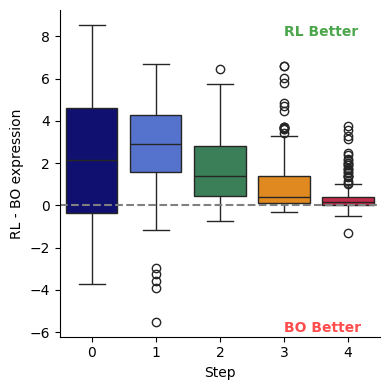

In [ ]:

colors = ['navy', 'royalblue', 'seagreen', 'darkorange', 'crimson']
plt.figure(figsize=(4, 4))
sns.boxplot(all_diffs,
            palette=colors)
plt.axhline(0, color='gray', linestyle='--')
plt.xlabel('Step')
plt.ylabel('RL - BO expression')
sns.despine()
plt.tight_layout()

plt.text(3, 8 , "RL Better", color='green', fontweight='bold', alpha=0.7)
plt.text(3, -6, "BO Better", color='red', fontweight='bold', alpha=0.7)
plt.savefig("rl_vs_bo_boxplot.pdf", format="pdf")
plt.show()